Model Accuracy Score: 0.9587233870967742
Mean Absolute Error: 1.2250000000000014

--- Predict Student Marks ---
Enter study hours: 5
Enter attendance (%): 94
Enter previous marks: 95
Predicted Final Marks: 80.32


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


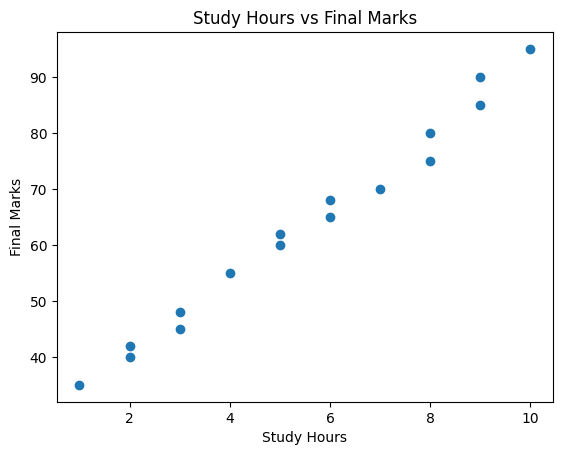

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Simulated realistic dataset (bigger)
data = {
    "StudyHours": [1,2,3,4,5,6,7,8,9,10,2,3,5,6,8,9],
    "Attendance": [50,55,60,65,70,75,80,85,90,95,58,62,72,78,88,92],
    "PreviousMarks": [30,35,40,50,55,60,65,70,80,90,38,42,57,63,75,85],
    "FinalMarks": [35,40,45,55,60,65,70,75,85,95,42,48,62,68,80,90]
}

df = pd.DataFrame(data)

# Features & target
X = df[["StudyHours", "Attendance", "PreviousMarks"]]
y = df["FinalMarks"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model (better than linear regression)
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Model Accuracy Score:", model.score(X_test, y_test))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# User input prediction
print("\n--- Predict Student Marks ---")
study = float(input("Enter study hours: "))
att = float(input("Enter attendance (%): "))
prev = float(input("Enter previous marks: "))

result = model.predict([[study, att, prev]])
print("Predicted Final Marks:", result[0])

# Visualization
plt.scatter(df["StudyHours"], df["FinalMarks"])
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")
plt.show()